In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import import_ipynb
from simca import SIMCAModel, SIMCAClassModel
%matplotlib inline

Replicate_011_20251119: 10 xvoo_none NIR files
Replicate_011_20251119 shape: (10, 228)
Replicate_012_20251119: 10 xvoo_none NIR files
Replicate_012_20251119 shape: (10, 228)
Replicate_021_20251119: 10 xvoo_none NIR files
Replicate_021_20251119 shape: (10, 228)
Replicate_022_20251119: 10 xvoo_none NIR files
Replicate_022_20251119 shape: (10, 228)


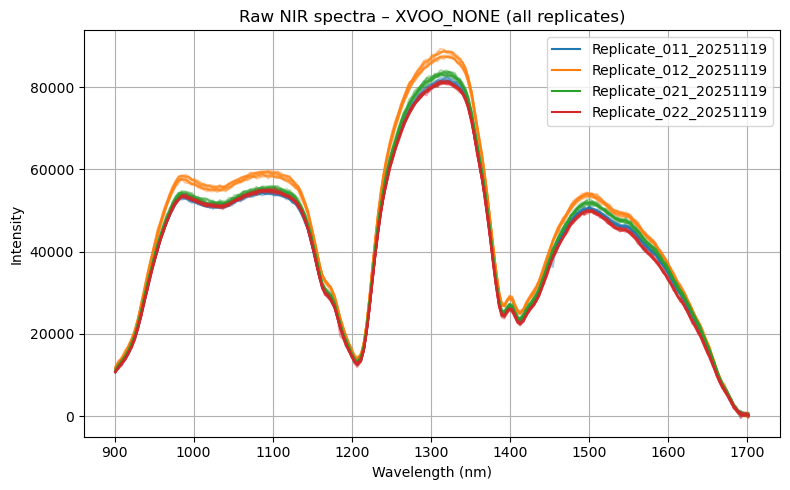

In [2]:
replicate_folders = [
    r"data/Replicate_011/Replicate_011_20251119",
    r"data/Replicate_012/Replicate_012_20251119",
    r"data/Replicate_021/Replicate_021_20251119",
    r"data/Replicate_022/Replicate_022_20251119",
    # r"data/Replicate_011/Replicate_011_20251230",
]

xvoo_none_raw_dict = {}
wavelengths_dict = {}

for base_folder in replicate_folders:
    rep_name = os.path.basename(base_folder)
    xvoo_none_nir_path = os.path.join(base_folder, "xvoo_none", "NIR")

    if not os.path.exists(xvoo_none_nir_path):
        print(f"Warning: {xvoo_none_nir_path} does not exist, skipping...")
        continue

    files = sorted(glob.glob(os.path.join(xvoo_none_nir_path, "*.csv")))
    print(f"{rep_name}: {len(files)} xvoo_none NIR files")

    spectra = []

    for i, fpath in enumerate(files):
        df = pd.read_csv(fpath)

        if i == 0:
            wavelengths_dict[rep_name] = df["x"].values
        else:
            assert np.allclose(
                wavelengths_dict[rep_name], df["x"].values
            ), f"Wavelengths do not match in {rep_name}"

        spectra.append(df["y"].values)

    xvoo_none_raw_dict[rep_name] = np.array(spectra)
    print(f"{rep_name} shape:", xvoo_none_raw_dict[rep_name].shape)
    
plt.figure(figsize=(8, 5))

rep_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for i, (rep_name, spectra) in enumerate(xvoo_none_raw_dict.items()):
    wavelengths = wavelengths_dict[rep_name]
    
    for spec in spectra:
        plt.plot(wavelengths, spec, color=rep_colors[i], alpha=0.4)
    
    plt.plot([], [], color=rep_colors[i], alpha=1, label=rep_name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Raw NIR spectra – XVOO_NONE (all replicates)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

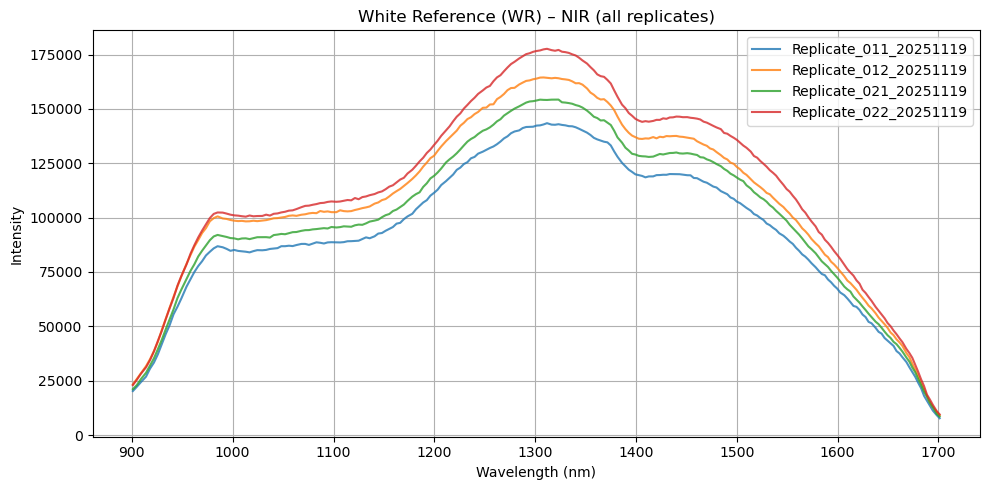

In [3]:
wr_nir_dict = {}

for base_folder in replicate_folders:
    rep_name = os.path.basename(base_folder)
    wr_path = os.path.join(base_folder, "wr", "NIR_WR.csv")

    if not os.path.exists(wr_path):
        print(f"Warning: WR does not exist for {rep_name}")
        continue

    wr_df = pd.read_csv(wr_path)
    wl_wr = wr_df["x"].values
    I_wr = wr_df["y"].values

    wr_nir_dict[rep_name] = I_wr

plt.figure(figsize=(10, 5))

for i, (rep_name, I_wr) in enumerate(wr_nir_dict.items()):
    wl_wr = wavelengths_dict[rep_name]
    plt.plot(wl_wr, I_wr, color=rep_colors[i], alpha=0.8, label=rep_name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("White Reference (WR) – NIR (all replicates)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Replicate_011_20251119 normalized shape: (10, 228)
Replicate_012_20251119 normalized shape: (10, 228)
Replicate_021_20251119 normalized shape: (10, 228)
Replicate_022_20251119 normalized shape: (10, 228)


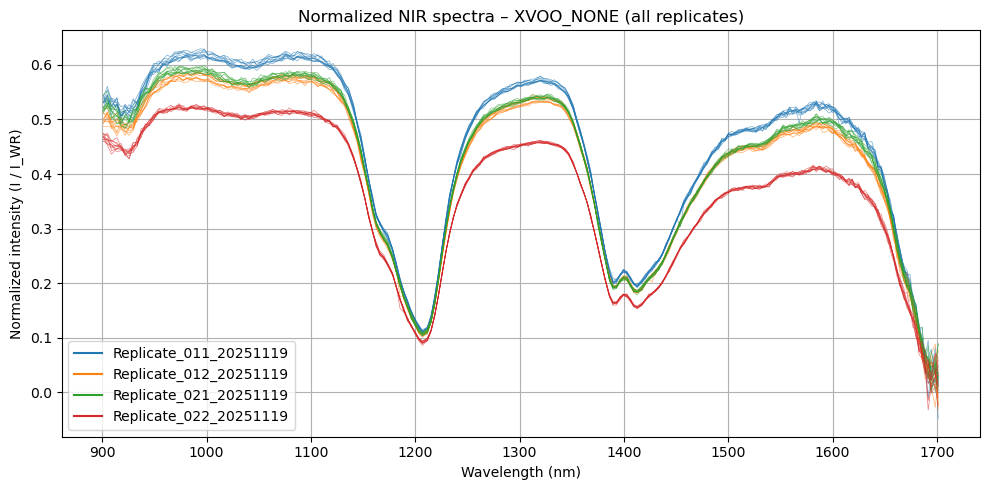

In [4]:
epsilon = 1e-10
xvoo_none_norm_dict = {}

for rep_name, spectra in xvoo_none_raw_dict.items():
    if rep_name not in wr_nir_dict:
        print(f"Skipping {rep_name} – no WR")
        continue

    wr = wr_nir_dict[rep_name]

    assert spectra.shape[1] == wr.shape[0], \
        f"Shape mismatch NIR za {rep_name}"

    use_filter = False
    if use_filter:
        max_ = np.max(spectra)
        to_filter = spectra < 0.1*max_
    xvoo_none_norm_dict[rep_name] = spectra / (wr + epsilon)
    if use_filter:
        xvoo_none_norm_dict[rep_name][to_filter] = 0

    print(f"{rep_name} normalized shape:", xvoo_none_norm_dict[rep_name].shape)
    
plt.figure(figsize=(10, 5))

for i, (rep_name, spectra_norm) in enumerate(xvoo_none_norm_dict.items()):
    wl = wavelengths_dict[rep_name]
    
    for spec in spectra_norm:
        plt.plot(wl, spec, color=rep_colors[i], alpha=0.6, lw=0.5)
    
    plt.plot([], [], color=rep_colors[i], alpha=1, label=rep_name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity (I / I_WR)")
plt.title("Normalized NIR spectra – XVOO_NONE (all replicates)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
X_list = []
for spectra_norm in xvoo_none_norm_dict.values():
    X_list.append(spectra_norm)

X = np.vstack(X_list)
y = np.array(["XVOO_NONE"] * X.shape[0])

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (40, 228)
Shape y: (40,)


Optimal number of PCA components per class: {'XVOO_NONE': 1}
SIMCA thresholds:
ODcrit: 0.009705384137635284
SDcrit: 4.1935605219491325
Inside class (True = sample accepted): [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True False  True  True  True  True
  True  True  True False  True  True  True  True  True  True  True  True
  True  True  True  True]


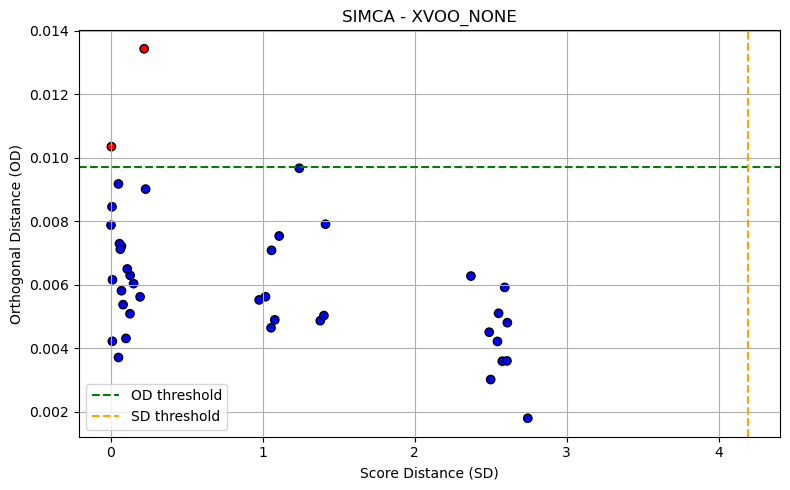

In [6]:
simca = SIMCAModel(alpha=0.05, default_n_components=None)

comp_grid = list(range(1, min(10, X.shape[1])+1))
best_components = simca.tune_num_components(
    X, y,
    comp_grid=comp_grid,
    cv=5,
    mode='rigorous',    # 'rigorous', 'compliant'
    rule='sim',         # 'sim', 'alt', 'ci', 'dd'
    od_method='percentile',    # 'percentile', 'jackson', 'box'
    sd_method='f'       # 'f', 'chi2', 'percentile'
)
print("Optimal number of PCA components per class:", best_components)

simca.fit(X, y, n_components=list(best_components.values())[0])

simca.set_thresholds_all(od_method='percentile', sd_method='f')

results = simca.predict(X, rule='sim')
res = results['XVOO_NONE']

print("SIMCA thresholds:")
print("ODcrit:", res.get('ODcrit', None))
print("SDcrit:", res.get('SDcrit', None))
print("Inside class (True = sample accepted):", res['inside'])

plt.figure(figsize=(8,5))
colors = np.where(res['inside'], 'blue', 'red')
plt.scatter(res['SD'], res['OD'], c=colors, edgecolor='k')
plt.axhline(simca.class_models['XVOO_NONE'].thresholds['ODcrit'], color='green', linestyle='--', label='OD threshold')
plt.axvline(simca.class_models['XVOO_NONE'].thresholds['SDcrit'], color='orange', linestyle='--', label='SD threshold')
plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA - XVOO_NONE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# plt.figure(figsize=(12,10))

# rules = {'SIMCA':'sim', 'Alt-SIMCA':'alt', 'CI-SIMCA':'ci', 'DD-SIMCA':'dd'}
# for i, (name, rule) in enumerate(rules.items(), 1):
#     res = simca.predict(X, rule=rule)['XVOO_NONE']
    
#     colors = ['blue' if flag else 'red' for flag in res['inside']]
    
#     plt.subplot(2,2,i)
#     plt.scatter(res['SD'], res['OD'], c=colors, edgecolor='k')
#     plt.axhline(simca.class_models['XVOO_NONE'].thresholds['ODcrit'], color='green', linestyle='--', label='OD threshold')
#     plt.axvline(simca.class_models['XVOO_NONE'].thresholds['SDcrit'], color='orange', linestyle='--', label='SD threshold')
#     plt.title(name)
#     plt.xlabel("SD")
#     plt.ylabel("OD")
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

In [8]:
datasets = [
    {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011\Replicate_011_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_none", "xvoo_oo50",
                     "xvoo_oo100", "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011\Replicate_011_20251205",
        "mixtures": ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40",
                     "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]
    },
    {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011\Replicate_011_20251230",
        "mixtures": ["xvoo_lso10", "xvoo_lso20", "xvoo_lso30", "xvoo_lso40",
                     "xvoo_lso60", "xvoo_lso70", "xvoo_lso80", "xvoo_lso90",
                     "xvoo_lso100", "xvoo_none", "xvoo_oo90"]
    },
    {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_012\Replicate_012_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_none",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_012\Replicate_012_20251205",
        "mixtures": ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40",
                     "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]
    },
        {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_021\Replicate_021_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_none",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
        {
        "base_folder": r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_022\Replicate_022_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_none",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    }
]

In [9]:
X_list = []
y_list = []

for ds in datasets:
    base_folder = ds["base_folder"]
    mixtures = ds["mixtures"]

    wr_file = os.path.join(base_folder, "wr", "NIR_WR.csv")
    wr = pd.read_csv(wr_file).iloc[:, 1].values

    print(f"\nUčitavam podatke iz: {base_folder}")
    print(f"WR shape: {wr.shape}")

    for mix in mixtures:
        nir_folder = os.path.join(base_folder, mix, "NIR")

        if not os.path.exists(nir_folder):
            print(f"Warning: folder does not exist {nir_folder}, skipping...")
            continue

        files = sorted([f for f in os.listdir(nir_folder) if f.endswith(".csv")])

        for f in files:
            df = pd.read_csv(os.path.join(nir_folder, f))
            spectrum = df.iloc[:, 1].values
            spectrum_norm = spectrum / 1.0

            X_list.append(spectrum_norm)
            y_list.append(mix)

X_all_norm = np.array(X_list)
y_all = np.array(y_list)

print("Shape X_all_norm:", X_all_norm.shape)
print("Shape y_all:", y_all.shape)

print("Unique classes:", np.unique(y_all))


Učitavam podatke iz: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011\Replicate_011_20251119
WR shape: (228,)

Učitavam podatke iz: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011\Replicate_011_20251205
WR shape: (228,)

Učitavam podatke iz: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011\Replicate_011_20251230
WR shape: (228,)

Učitavam podatke iz: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_012\Replicate_012_20251119
WR shape: (228,)

Učitavam podatke iz: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_012\Replicate_012_20251205
WR shape: (228,)

Učitavam podatke iz: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_021\Replicate_021_20251119
WR shape: (228,)

Učitavam podatke iz: C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_022\Replicate_022_20251119
WR shape: (228,)
Shape X_all_norm: (1050, 228)
Shape y_all: (1050,)
Unique classes: ['xvoo_lso10' 'xvoo_lso100' 'xvoo_lso20' 'xvoo_lso30' 'xvoo_lso40

In [10]:
results_mix = simca.predict(X_all_norm, rule='sim')
res_mix = results_mix['XVOO_NONE']

ODcrit = simca.class_models['XVOO_NONE'].thresholds['ODcrit']
SDcrit = simca.class_models['XVOO_NONE'].thresholds['SDcrit']

print("OD threshold:", ODcrit)
print("SD threshold:", SDcrit)

inside = res_mix['inside']
# for i, accepted in enumerate(inside):
#     print(f"Sample {i} ({y_all[i]}): {'Accepted' if accepted else 'Rejected'}")

OD threshold: 0.009705384137635284
SD threshold: 4.1935605219491325


In [11]:
%matplotlib qt

In [12]:
SD = res_mix['SD']
OD = res_mix['OD']

classes = np.unique(y_all)

contrast_colors = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#ffff33",
    "#a65628",
    "#f781bf",
    "#999999",
]

class_colors = {cls: contrast_colors[i % len(contrast_colors)] for i, cls in enumerate(classes)}

plt.figure(figsize=(8,5))

for cls in classes:
    idx = y_all == cls
    plt.scatter(
        SD[idx],
        OD[idx],
        color=class_colors[cls],
        edgecolor='k',
        label=cls,
        s=60
    )

plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')

plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA – All XVOO data by class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# class_colors = {cls: contrast_colors[i % len(contrast_colors)] for i, cls in enumerate(classes)}

# plt.figure(figsize=(8,5))

# for cls in classes:
#     idx = (y_all == cls)
#     plt.scatter(
#         SD[idx],
#         OD[idx],
#         color=class_colors[cls],
#         edgecolor='k',
#         label=cls,
#         s=60
#     )

# plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
# plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')

# plt.xlabel("Score Distance (SD)")
# plt.ylabel("Orthogonal Distance (OD)")
# plt.title("SIMCA – zoom around rejected samples")

# plt.xlim(450, 850)
# plt.ylim(0.5, 1)

# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [14]:
# plt.figure(figsize=(8,5))

# class_colors = {cls: contrast_colors[i % len(contrast_colors)] for i, cls in enumerate(classes)}

# for cls in classes:
#     idx = (y_all == cls)
#     plt.scatter(
#         res_mix['SD'][idx],
#         res_mix['OD'][idx],
#         color=class_colors[cls],
#         edgecolor='k',
#         label=cls,
#         s=60
#     )

# plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
# plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')

# plt.xlim(0, SDcrit * 5)
# plt.ylim(0, ODcrit * 5)

# plt.xlabel("Score Distance (SD)")
# plt.ylabel("Orthogonal Distance (OD)")
# plt.title("SIMCA – zoom around decision region")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [15]:
y_true = np.array([label == "xvoo_none" for label in y_all])

y_pred = res_mix['inside']

TP = np.sum((y_true == True) & (y_pred == True))
FN = np.sum((y_true == True) & (y_pred == False))
FP = np.sum((y_true == False) & (y_pred == True))
TN = np.sum((y_true == False) & (y_pred == False))

conf_matrix = pd.DataFrame(
    [[TP, FN],
     [FP, TN]],
    index=["True XVOO", "True MIX"],
    columns=["Predicted IN", "Predicted OUT"]
)

conf_matrix

,Predicted IN,Predicted OUT
True XVOO,0,90
True MIX,0,960


In [16]:
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Sensitivity (Recall for XVOO): {sensitivity*100:.2f}%")
print(f"Specificity (Rejection of MIX): {specificity*100:.2f}%")
print(f"Accuracy: {accuracy*100:.2f}%")

Sensitivity (Recall for XVOO): 0.00%
Specificity (Rejection of MIX): 100.00%
Accuracy: 91.43%


In [17]:
results_table = pd.DataFrame({
    "Sample index": np.arange(len(y_all)),
    "True label": y_all,
    "SIMCA accepted": y_pred,
    "Decision": np.where(y_pred, "Accepted", "Rejected"),
    "SD": res_mix['SD'],
    "OD": res_mix['OD']
})

results_table.head(10)

,Sample index,True label,SIMCA accepted,Decision,SD,OD
0,0,xvoo_lso50,False,Rejected,1.835047e+12,4.876079e+10
1,1,xvoo_lso50,False,Rejected,1.831807e+12,4.904635e+10
2,2,xvoo_lso50,False,Rejected,1.838253e+12,4.878567e+10
3,3,xvoo_lso50,False,Rejected,1.819140e+12,4.859909e+10
4,4,xvoo_lso50,False,Rejected,1.837674e+12,4.886363e+10
5,5,xvoo_lso50,False,Rejected,1.830198e+12,4.871366e+10
6,6,xvoo_lso50,False,Rejected,1.834163e+12,4.851508e+10
7,7,xvoo_lso50,False,Rejected,1.827273e+12,4.844255e+10
8,8,xvoo_lso50,False,Rejected,1.846350e+12,4.880204e+10
9,9,xvoo_lso50,False,Rejected,1.831334e+12,4.848495e+10
